### Step 1: Import Libraries
Load `pandas`/`numpy`, plotting libraries, and `pearsonr`/`ttest_ind` from `scipy.stats`.

In [38]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import ttest_ind

### Step 2: Load Dataset
Read the smartphone dataset from `Dataset.xlsx`.

In [ ]:
df = pd.read_excel('Dataset.xlsx')

### Step 3: RAM Value Counts
Check how many phones exist for each RAM capacity in the dataset.

In [40]:
df["RAM"].value_counts()

RAM
8     1888
6     1408
4     1208
12     673
3      218
2      145
16      85
24       1
10       1
Name: count, dtype: int64

### Step 4: Filter to 4GB vs 8GB RAM
Keep only phones with 4 GB or 8 GB RAM for a two-group comparison.

In [41]:
ram_df = df[df["RAM"].isin([4.0, 8.0])].copy()

### Step 5: Verify Filtered Counts
Confirm the filtered dataset now only contains 4 GB and 8 GB RAM phones.

In [42]:
ram_df["RAM"].value_counts()

RAM
8    1888
4    1208
Name: count, dtype: int64

### Step 6: Mean Rating by RAM
Compute average rating for each RAM group.

In [43]:
ram_df.groupby("RAM")["Rating"].mean()

RAM
4    4.192219
8    4.292373
Name: Rating, dtype: float64

### Step 7: Median Rating by RAM
Compute median rating for each RAM group.

In [44]:
ram_df.groupby("RAM")["Rating"].median()

RAM
4    4.2
8    4.3
Name: Rating, dtype: float64

### Step 8: Rating Standard Deviation by RAM
Measure rating variability within each RAM group.

In [45]:
ram_df.groupby("RAM")["Rating"].std()

RAM
4    0.172094
8    0.189902
Name: Rating, dtype: float64

### Step 9: Full Descriptive Statistics
Generate complete descriptive stats (count, mean, std, quartiles) for ratings by RAM group.

In [46]:
ram_df.groupby("RAM")["Rating"].describe()

,count,mean,std,min,25%,50%,75%,max
RAM,,,,,,,,
4,1208.0,4.192219,0.172094,2.6,4.1,4.2,4.3,4.7
8,1888.0,4.292373,0.189902,2.3,4.2,4.3,4.4,4.8


### Step 10: Boxplot of Ratings by RAM
Visualize rating distribution for 4 GB vs 8 GB RAM phones.

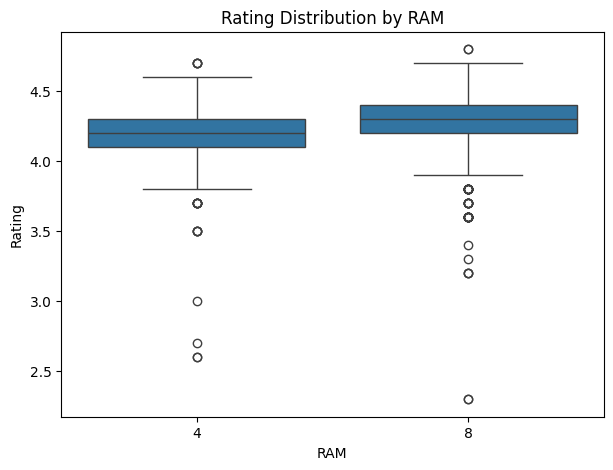

In [47]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=ram_df,
    x="RAM",
    y="Rating"
)

plt.title("Rating Distribution by RAM")

plt.show()

### Step 11: Welch's t-test
Split ratings by RAM group and run an independent t-test (unequal variances) to compare means; print the t-statistic and p-value.

In [48]:
ram_4 = ram_df[ram_df["RAM"] == 4.0]["Rating"]
ram_8 = ram_df[ram_df["RAM"] == 8.0]["Rating"]

t_stat, p_value = ttest_ind(
    ram_4,
    ram_8,
    equal_var=False  # Welch's t-test
)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: -15.164849468232443
P Value: 5.968700552579282e-50


### Step 12: Hypothesis Decision
Compare the p-value to α = 0.05 and report whether to reject the null hypothesis.

In [49]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis")
else:
    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


### Business Problem
Do smartphones with 8 GB RAM receive better customer ratings than those with 4 GB RAM?

### Hypotheses
**H₀:** There is no significant difference in average ratings between 4 GB and 8 GB RAM smartphones.  
**H₁:** There is a significant difference in average ratings between 4 GB and 8 GB RAM smartphones.

### Statistical Test
Welch's Independent t-test (unequal variances assumed)

### Results
| Metric | Value |
|--------|-------|
| t-statistic | -15.16 |
| p-value | 5.96 × 10⁻⁵⁰ |

| Group | Mean | Std Dev | n |
|-------|------|---------|---|
| 4 GB | 4.19  | 0.17  | 1,208 |
| 8 GB | 4.29  | 0.18  | 1,888 |

### Decision
Since p-value (5.96 × 10⁻⁵⁰) < α (0.05), **reject the null hypothesis.**

### Business Insight
A statistically significant difference was found between 4 GB and 8 GB RAM smartphones (t = -15.64, p < 0.001). The 8 GB group has a slightly higher average rating (4.295) compared to the 4 GB group (4.192). However, the actual rating difference is only ~0.10 stars, which is practically small despite being statistically significant. This suggests that while 8 GB RAM phones tend to rate better, the difference is modest. Higher RAM devices also typically include other premium features (better processors, cameras, displays) that likely contribute to the higher ratings. RAM alone is not the sole driver of customer satisfaction.